# Actividad 2 - Prediccion del Exam_Score

**Dataset:** Student Performance Factors Dataset

**Fuente:** Abdel-Ghany, M. (2025). Student Performance Factors Dataset.

**Liga:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset

**Fecha de consulta:** 21 de agosto de 2026

**De que trata el dataset:** son datos de 6,607 estudiantes con info academica (horas de estudio, asistencia, calificaciones previas, tutorias), personal (sueño, actividad fisica, motivacion), familiar (participacion de los padres, ingreso familiar, nivel educativo de los padres) y de la escuela (tipo de escuela, calidad del profesor, acceso a recursos). Cada fila es un estudiante distinto.

**Variable objetivo:** `Exam_Score`, el puntaje que sacó el estudiante en el examen.

**Pregunta que quiero contestar:** ¿que tanto me sirven las caracteristicas academicas, personales, familiares y escolares de los estudiantes para estimar el puntaje que van a sacar en su examen usando un modelo de regresion?


In [1]:
# librerias que voy a usar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42  # semilla fija para que siempre me de lo mismo


## 1. Cargo el dataset y le echo un ojo

In [2]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df.shape


(6607, 20)

In [3]:
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
# tipos de dato de cada columna
df.dtypes


Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [5]:
# cuantos nulos tiene cada columna
df.isnull().sum()


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
print('filas duplicadas:', df.duplicated().sum())


filas duplicadas: 0


## 2. Limpieza

Nada mas encontre un problema real: hay un estudiante con `Exam_Score` de 101, y el examen es sobre 100, asi que ese dato esta mal y lo quito.

Los nulos que salieron arriba (en `Teacher_Quality`, `Parental_Education_Level` y `Distance_from_Home`) son poquitos (menos del 1.5% de las filas), asi que no los relleno aqui a mano. Los voy a rellenar mas adelante pero dentro del pipeline, para que el relleno se calcule solo con los datos de entrenamiento y no se mezcle info del test con el train (eso seria fuga de datos).

No hay duplicados y los tipos de dato ya estan bien, entonces no tengo que convertir nada.


In [7]:
print('filas antes:', df.shape[0])
df = df[df['Exam_Score'] <= 100].reset_index(drop=True)
print('filas despues:', df.shape[0])


filas antes: 6607
filas despues: 6606


## 3. Como se ve mi variable objetivo (Exam_Score)

In [8]:
df['Exam_Score'].describe()


count    6606.000000
mean       67.230548
std         3.868502
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

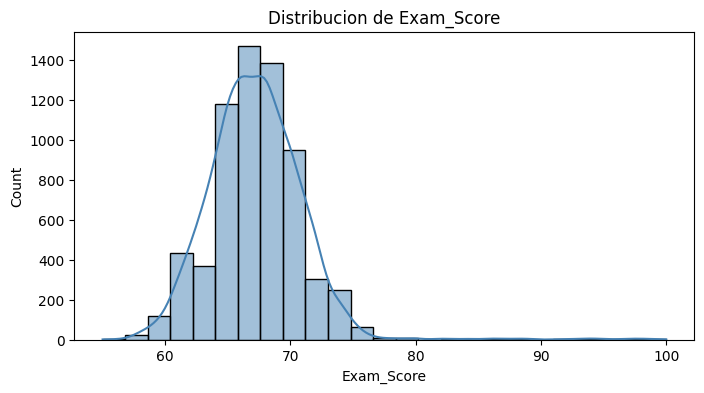

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Exam_Score'], bins=25, kde=True, color='steelblue')
plt.title('Distribucion de Exam_Score')
plt.xlabel('Exam_Score')
plt.show()


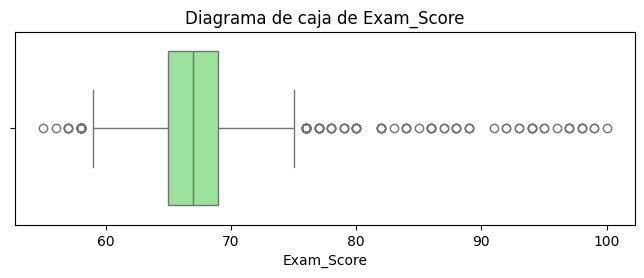

In [10]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['Exam_Score'], color='lightgreen')
plt.title('Diagrama de caja de Exam_Score')
plt.show()


La mayoria de los estudiantes esta entre 60 y 75 puntos, el promedio anda como en 67. En el diagrama de caja se ven algunos puntos arriba de 80 que salen como atipicos, son pocos pero ahi estan.

## 4. Relacion de Exam_Score con las demas variables

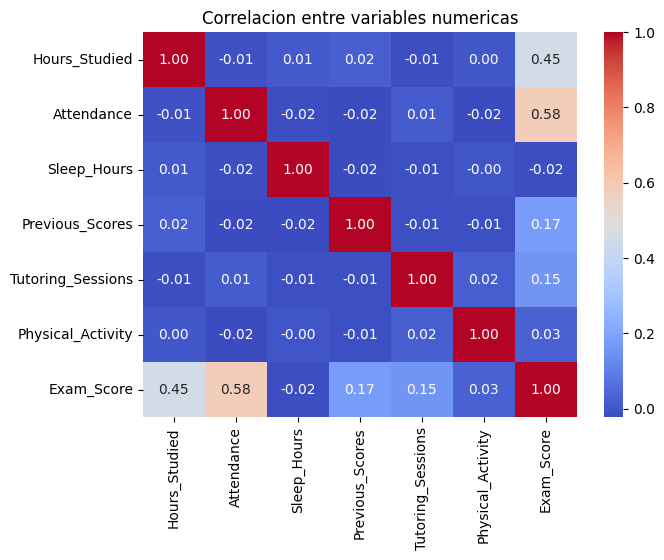

In [11]:
cols_numericas = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                   'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

plt.figure(figsize=(7, 5))
sns.heatmap(df[cols_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlacion entre variables numericas')
plt.show()


In [12]:
df[cols_numericas].corr()['Exam_Score'].sort_values(ascending=False)


Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64

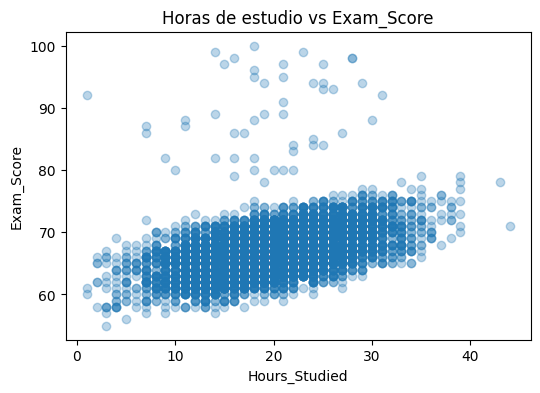

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.3)
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.title('Horas de estudio vs Exam_Score')
plt.show()


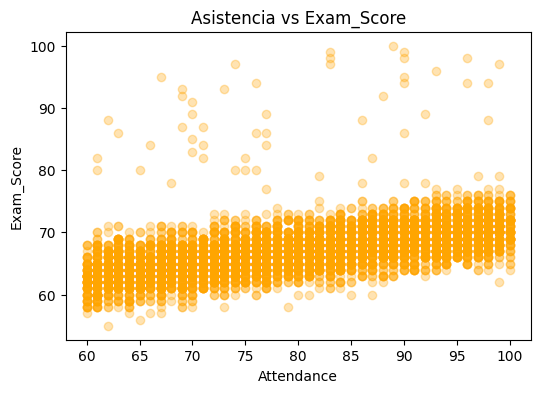

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Attendance'], df['Exam_Score'], alpha=0.3, color='orange')
plt.xlabel('Attendance')
plt.ylabel('Exam_Score')
plt.title('Asistencia vs Exam_Score')
plt.show()


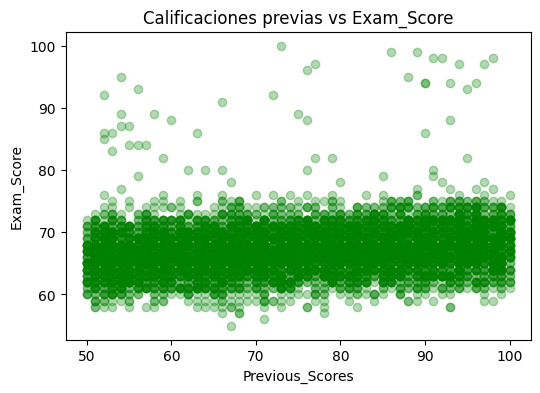

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Previous_Scores'], df['Exam_Score'], alpha=0.3, color='green')
plt.xlabel('Previous_Scores')
plt.ylabel('Exam_Score')
plt.title('Calificaciones previas vs Exam_Score')
plt.show()


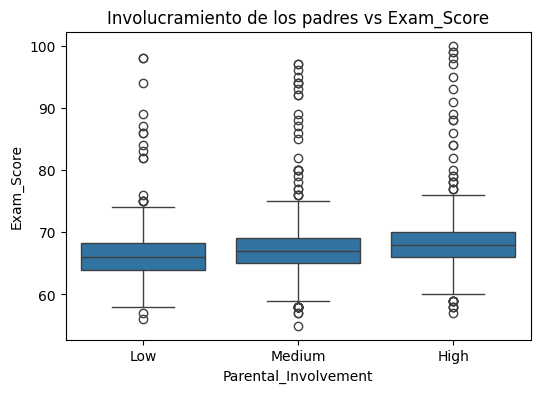

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', order=['Low', 'Medium', 'High'])
plt.title('Involucramiento de los padres vs Exam_Score')
plt.show()


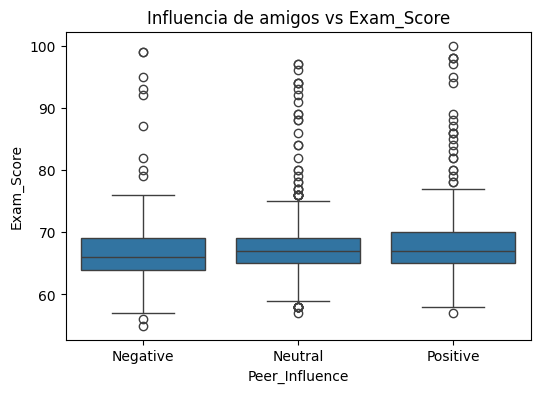

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Peer_Influence', y='Exam_Score', order=['Negative', 'Neutral', 'Positive'])
plt.title('Influencia de amigos vs Exam_Score')
plt.show()


In [18]:
# reviso el promedio de Exam_Score por categoria en cada variable categorica
# para ver cuales si cambian entre categorias y cuales no
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
            'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for col in cat_cols:
    medias = df.groupby(col)['Exam_Score'].mean()
    print(col, '-> diferencia entre categorias:', round(medias.max() - medias.min(), 2))


Parental_Involvement -> diferencia entre categorias: 1.76
Access_to_Resources -> diferencia entre categorias: 1.89
Extracurricular_Activities -> diferencia entre categorias: 0.5
Motivation_Level -> diferencia entre categorias: 0.97
Internet_Access -> diferencia entre categorias: 0.83
Family_Income -> diferencia entre categorias: 0.97
Teacher_Quality -> diferencia entre categorias: 0.91
School_Type -> diferencia entre categorias: 0.08
Peer_Influence -> diferencia entre categorias: 1.05
Learning_Disabilities -> diferencia entre categorias: 1.07
Parental_Education_Level -> diferencia entre categorias: 1.09
Distance_from_Home -> diferencia entre categorias: 1.05
Gender -> diferencia entre categorias: 0.0


## 5. Que variables voy a usar

Con lo de arriba, decidi lo siguiente:

Numericas que si uso: `Hours_Studied`, `Attendance`, `Previous_Scores` y `Tutoring_Sessions`, porque son las que tienen correlacion de verdad con `Exam_Score` (sobre todo `Attendance` y `Hours_Studied`). `Sleep_Hours` y `Physical_Activity` las quito porque su correlacion es casi cero, no aportan nada.

Categoricas que si uso: `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`, `Peer_Influence`, `Parental_Education_Level`, `Distance_from_Home`, `Internet_Access`, `Extracurricular_Activities` y `Learning_Disabilities`, porque en todas estas si cambia el promedio de `Exam_Score` entre categorias.

Categoricas que quito: `Gender` y `School_Type`, porque la diferencia entre sus categorias es minima o nula, no parecen influir en nada.


In [19]:
num_cols = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']

# estas si tienen un orden claro (de menos a mas)
ord_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
            'Family_Income', 'Teacher_Quality', 'Parental_Education_Level',
            'Distance_from_Home']

# estas no tienen un orden logico
nom_cols = ['Peer_Influence', 'Internet_Access', 'Extracurricular_Activities',
            'Learning_Disabilities']

cols_finales = num_cols + ord_cols + nom_cols
len(cols_finales)


15

## 6. Defino X, y y separo entrenamiento/prueba

In [20]:
X = df[cols_finales]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(X_train.shape, X_test.shape)


(5284, 15) (1322, 15)


Uso `random_state=SEED` para que la separacion de datos sea siempre la misma cada vez que corro el notebook. Si no le pongo semilla, cada vez que ejecute me tocarian estudiantes distintos en el grupo de prueba y las metricas cambiarian solo por azar, no porque el modelo haya cambiado. Con la semilla fija puedo comparar los modelos de forma justa y si alguien mas corre mi notebook le va a dar exactamente lo mismo.

## 7. Pipeline de preprocesamiento

Aqui armo las transformaciones. Como tengo 3 tipos de variable distinto, cada una necesita su propio tratamiento:

- Numericas: relleno nulos con la mediana y las escalo (`StandardScaler`).
- Ordinales (las que tienen orden Low/Medium/High, etc): relleno con la moda y las paso a numero con `OrdinalEncoder`, respetando el orden.
- Nominales (sin orden): relleno con la moda y uso `OneHotEncoder`.

Todo esto lo meto en un `ColumnTransformer` y despues en un `Pipeline` junto con el modelo, para que el ajuste (fit) del preprocesamiento se haga nada mas con los datos de entrenamiento.


In [21]:
orden_categorias = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['High School', 'College', 'Postgraduate'],
    ['Near', 'Moderate', 'Far'],
]

trans_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

trans_ord = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=orden_categorias))
])

trans_nom = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', trans_num, num_cols),
    ('ord', trans_ord, ord_cols),
    ('nom', trans_nom, nom_cols)
])


## 8. Linea base

Antes de entrenar algo "de verdad", hago una linea base con `DummyRegressor` que solo predice el promedio de `Exam_Score`. Esto me sirve para saber si mis modelos realmente estan aprendiendo algo o no.


In [22]:
modelo_base = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', DummyRegressor(strategy='mean'))
])

modelo_base.fit(X_train, y_train)
pred_base = modelo_base.predict(X_test)
print('la linea base siempre predice:', round(pred_base[0], 2))


la linea base siempre predice: 67.26


## 9. Entreno los modelos

Primero una regresion lineal normal. Como segundo modelo uso Ridge, que es casi lo mismo pero le agrega una penalizacion a los coeficientes (regularizacion). Elegi Ridge porque con el One-Hot Encoding se generan bastantes columnas y algunas pueden estar correlacionadas entre si, y Ridge ayuda a que el modelo no se vuelva inestable por eso, sin tener que quitar variables como haria Lasso.


In [23]:
modelo_lineal = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', LinearRegression())
])

modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)
print('listo, regresion lineal entrenada')


listo, regresion lineal entrenada


In [24]:
modelo_ridge = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', Ridge(alpha=1.0, random_state=SEED))
])

modelo_ridge.fit(X_train, y_train)
pred_ridge = modelo_ridge.predict(X_test)
print('listo, ridge entrenado')


listo, ridge entrenado


## 10. Comparo los 3 con MAE, RMSE y R2

In [25]:
def sacar_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = mean_squared_error(y_real, y_pred) ** 0.5
    r2 = r2_score(y_real, y_pred)
    return mae, rmse, r2

tabla = pd.DataFrame([
    ['Linea base'] + list(sacar_metricas(y_test, pred_base)),
    ['Regresion lineal'] + list(sacar_metricas(y_test, pred_lineal)),
    ['Ridge'] + list(sacar_metricas(y_test, pred_ridge)),
], columns=['Modelo', 'MAE', 'RMSE', 'R2'])

tabla.round(3)


,Modelo,MAE,RMSE,R2
0,Linea base,2.763,3.640,-0.002
1,Regresion lineal,0.460,1.537,0.821
2,Ridge,0.460,1.537,0.821


Mi variable objetivo tiene un promedio de 67.23 y una desviacion estandar de 3.87 (o sea, la mayoria de los estudiantes esta entre 63 y 71 puntos). Con eso en mente, lo que me dio la tabla:

La linea base (que solo predice el promedio) se equivoca en promedio 2.76 puntos (MAE) y su R2 es practicamente 0, como era de esperarse porque no usa ninguna variable.

Regresion lineal y Ridge me dieron practicamente lo mismo: MAE de 0.46, RMSE de 1.54 y R2 de 0.821. Que Ridge no haya cambiado casi nada tiene sentido, porque mis variables no tienen tanta multicolinealidad como para que la regularizacion haga una gran diferencia.

Para interpretar esto: el MAE de 0.46 significa que en promedio mi modelo le atina al puntaje real por menos de medio punto, lo cual esta muy bien si lo comparo contra la desviacion estandar de 3.87 (mi error es como una octava parte de esa desviacion). El RMSE (1.54) sale mas alto que el MAE porque castiga mas fuerte a los errores grandes, y como voy a ver en la seccion 13, hay algunos casos donde me equivoco por mas de 15-29 puntos (estudiantes con Exam_Score muy alto), y esos pocos casos "extremos" suben el RMSE aunque la mayoria de mis predicciones esten muy cerca del valor real. El R2 de 0.821 quiere decir que mi modelo explica como el 82% de la variacion del Exam_Score, contra el modelo base que no explica nada. Osea que las variables que elegi si sirven para predecir el desempeño del examen, aunque falta ese ultimo 18% que seguro tiene que ver con cosas que no estan en el dataset (como el animo del estudiante ese dia o que tan dificil estuvo el examen).

## 11. Valores reales vs predichos

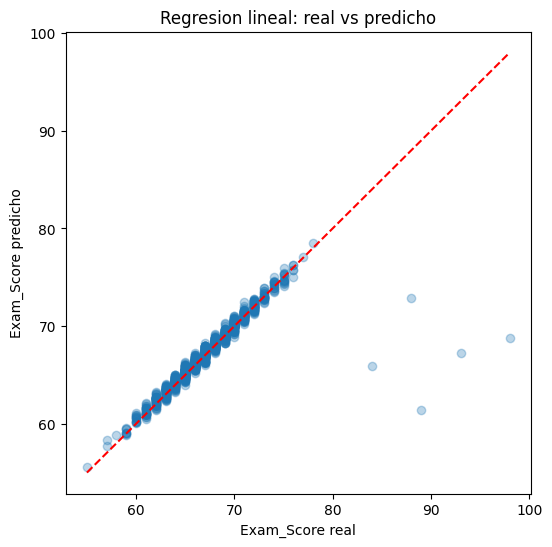

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_lineal, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Exam_Score real')
plt.ylabel('Exam_Score predicho')
plt.title('Regresion lineal: real vs predicho')
plt.show()


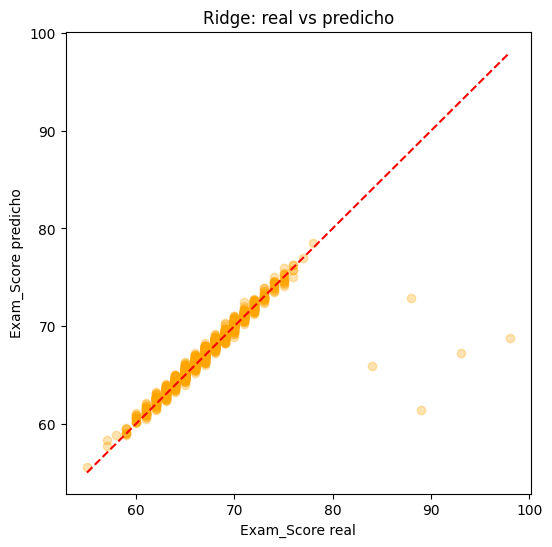

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_ridge, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Exam_Score real')
plt.ylabel('Exam_Score predicho')
plt.title('Ridge: real vs predicho')
plt.show()


## 12. Residuos del mejor modelo

In [28]:
# checo cual de los dos dio mejor RMSE para usar ese en el analisis de residuos
rmse_lineal = tabla.loc[tabla['Modelo'] == 'Regresion lineal', 'RMSE'].values[0]
rmse_ridge = tabla.loc[tabla['Modelo'] == 'Ridge', 'RMSE'].values[0]

if rmse_ridge <= rmse_lineal:
    mejor = 'Ridge'
    pred_mejor = pred_ridge
    modelo_mejor = modelo_ridge
else:
    mejor = 'Regresion lineal'
    pred_mejor = pred_lineal
    modelo_mejor = modelo_lineal

print('el mejor modelo fue:', mejor)
residuos = y_test.values - pred_mejor


el mejor modelo fue: Regresion lineal


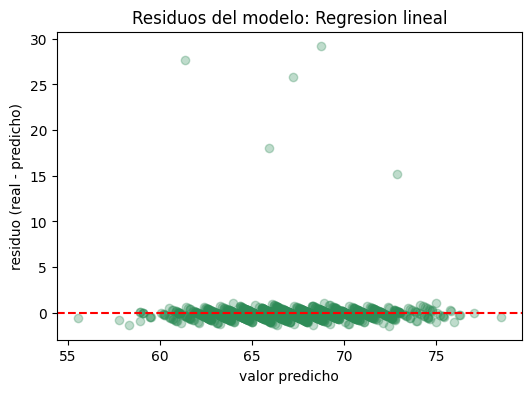

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(pred_mejor, residuos, alpha=0.3, color='seagreen')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('valor predicho')
plt.ylabel('residuo (real - predicho)')
plt.title(f'Residuos del modelo: {mejor}')
plt.show()


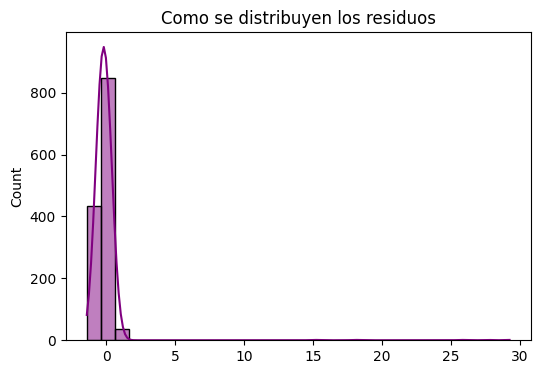

In [30]:
plt.figure(figsize=(6, 4))
sns.histplot(residuos, bins=30, kde=True, color='purple')
plt.title('Como se distribuyen los residuos')
plt.show()


Los residuos se ven bastante centrados en 0 y sin un patron raro para la mayoria de los casos, lo cual esta bien. Pero si se nota que hay unos cuantos puntos con residuo positivo grande, sobre todo en la parte donde el modelo predijo valores bajos: son estudiantes que sacaron un Exam_Score real bastante mas alto de lo que el modelo esperaba. Esto probablemente pasa porque mi modelo es lineal y tiende a "jalar" las predicciones hacia el promedio, entonces le cuesta trabajo anticipar a los estudiantes que sacaron puntajes fuera de lo comun (los mismos que se veian como atipicos en el boxplot de la seccion 3).

## 13. Los casos donde mas me equivoco vs los que mejor prediigo

In [31]:
resultado_test = X_test.copy()
resultado_test['real'] = y_test.values
resultado_test['prediccion'] = pred_mejor.round(2)
resultado_test['error_abs'] = abs(residuos).round(2)

resultado_test.sort_values('error_abs', ascending=False).head(5)


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Parental_Education_Level,Distance_from_Home,Peer_Influence,Internet_Access,Extracurricular_Activities,Learning_Disabilities,real,prediccion,error_abs
6392,16,83,92,2,Low,Medium,Low,High,High,Postgraduate,Near,Positive,Yes,Yes,No,98,68.75,29.25
217,19,70,54,0,Medium,Low,High,Medium,Medium,High School,Moderate,Positive,Yes,No,Yes,89,61.36,27.64
4582,25,73,56,2,Medium,Medium,Medium,High,Medium,High School,Near,Neutral,Yes,Yes,No,93,67.20,25.80
3931,25,66,55,4,High,Medium,Medium,Medium,Medium,High School,Moderate,Neutral,Yes,Yes,Yes,84,65.91,18.09
1606,30,98,93,1,Medium,Low,Medium,Low,Low,High School,Near,Positive,Yes,Yes,No,88,72.85,15.15


In [32]:
resultado_test.sort_values('error_abs', ascending=True).head(5)


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Parental_Education_Level,Distance_from_Home,Peer_Influence,Internet_Access,Extracurricular_Activities,Learning_Disabilities,real,prediccion,error_abs
4076,8,65,74,1,Medium,Medium,Medium,Medium,High,High School,Near,Positive,Yes,No,No,61,61.0,0.0
604,22,72,64,1,High,Medium,Low,Medium,Medium,College,Near,Negative,Yes,Yes,No,66,66.0,0.0
3482,20,85,75,1,Low,Medium,Low,Medium,Medium,College,Near,Neutral,Yes,Yes,No,67,67.0,0.0
6292,23,64,60,2,High,Medium,Low,Medium,Medium,College,Near,Negative,Yes,Yes,No,65,65.0,0.0
1425,8,88,92,1,Medium,Medium,High,Low,Medium,College,Near,Negative,Yes,Yes,No,66,66.0,0.0


El peor caso (error de 29.25 puntos) es un estudiante que solo estudio 16 horas y tuvo 83% de asistencia, pero saco 98 en el examen — mi modelo predijo 68.75. Los otros errores grandes se parecen: estudiantes con horas de estudio y asistencia mas bien normales pero que sacaron un puntaje real muy alto (89, 93, 84, 88). En cambio, en los casos donde casi no me equivoco (error de 0), los estudiantes tienen un perfil bastante tipico, cercano al promedio del dataset en horas de estudio, asistencia y calificaciones previas.

Con esto creo que el problema no es del preprocesamiento ni necesariamente del tipo de modelo, sino que estas variables no alcanzan a explicar por que ciertos estudiantes sacan puntajes tan altos. Puede ser que haya factores que no estan en el dataset (motivacion real ese dia, dificultad del examen, o simplemente que un estudiante le entendio mejor al tema) que no puedo capturar con lo que tengo. Un modelo no lineal (como un arbol) tal vez agarraria mejor alguna interaccion entre variables, pero dudo que resuelva del todo el problema si la info relevante no esta en los datos.

## 14. Validacion cruzada (5-fold) del mejor modelo

Aqui aplico validacion cruzada de 5 particiones sobre el set de entrenamiento nada mas, usando el pipeline completo para que en cada fold el preprocesamiento se ajuste solo con los datos de entrenamiento de ese fold (y no se mezcle info del fold de validacion).


In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

rmse_cv = -cross_val_score(modelo_mejor, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf)
r2_cv = cross_val_score(modelo_mejor, X_train, y_train, scoring='r2', cv=kf)

print('RMSE en cada fold:', rmse_cv.round(3))
print('RMSE promedio:', round(rmse_cv.mean(), 3), '+/-', round(rmse_cv.std(), 3))
print()
print('R2 en cada fold:', r2_cv.round(3))
print('R2 promedio:', round(r2_cv.mean(), 3), '+/-', round(r2_cv.std(), 3))


RMSE en cada fold: [1.883 2.464 2.648 1.617 1.827]
RMSE promedio: 2.088 +/- 0.397

R2 en cada fold: [0.752 0.652 0.61  0.802 0.762]
R2 promedio: 0.716 +/- 0.072


Aqui si hubo una diferencia que vale la pena comentar: con la particion unica de train/test me dio un RMSE de 1.537, pero con validacion cruzada de 5 folds me dio un RMSE promedio de 2.088 (+/- 0.397), y el R2 promedio bajo a 0.716 (contra el 0.821 de la particion unica). Ademas los folds variaron bastante entre si (RMSE de 1.62 hasta 2.65, R2 de 0.61 hasta 0.80).

Esto me dice que mi particion de prueba original le toco, por pura suerte, una muestra mas facil de predecir que el promedio. Justo por eso la validacion cruzada es mejor referencia: si solo me hubiera quedado con el resultado de una sola particion, hubiera pensado que mi modelo es mejor de lo que realmente es en general. Al promediar 5 particiones distintas veo que tan estable es en realidad el desempeño, y me doy cuenta que si varia dependiendo de que estudiantes caen en el set de prueba.

## 15. Conclusion

En este caso Regresion lineal y Ridge me dieron resultados practicamente iguales (MAE 0.46, RMSE 1.537 los dos, R2 0.821 los dos), asi que no hubo una ventaja real de usar Ridge aqui — tiene sentido porque mis variables no tenian tanta multicolinealidad como para que la regularizacion cambiara mucho las cosas. Para el analisis de residuos me quede con Regresion lineal por una diferencia minima.

Comparando contra la linea base, la mejora es bastante clara: pase de un R2 de -0.002 (practicamente nada) a 0.821, y el MAE bajo de 2.76 a 0.46 puntos, o sea una reduccion de mas del 80% en el error promedio.

Las variables que mas ayudaron fueron `Attendance` y `Hours_Studied`, por mucho margen (son las que tenian mas correlacion desde el principio). `Previous_Scores` y `Tutoring_Sessions` tambien aportan pero menos, y las variables familiares/escolares (participacion de los padres, acceso a recursos, influencia de amigos, etc) suman un poco cada una aunque individualmente su efecto es chico.

Limitaciones que note:
- El modelo falla bastante en los estudiantes que sacaron un Exam_Score real muy alto, los subestima de forma sistematica.
- Con validacion cruzada vi que el resultado de mi particion de prueba fue mas optimista que el promedio real (RMSE de 1.54 vs 2.09 en CV), asi que hay que tomar el resultado de una sola particion con cautela.
- Es un modelo lineal, no capta si el efecto de una variable cambia dependiendo de otra (por ejemplo que estudiar mucho ayude mas si ademas hay alta motivacion).
- El dataset no tiene variables que quizas expliquen mejor esos casos atipicos (animo, dificultad del examen, calidad real del estudio y no solo horas).

Como siguiente paso propondria probar un modelo no lineal, como un arbol de regresion o algo tipo Random Forest, para ver si logra capturar mejor esas interacciones y bajar el error en los casos con puntaje alto. Tambien se podrian crear variables nuevas (por ejemplo cruzar horas de estudio con motivacion) o conseguir mas variables relacionadas con el bienestar del estudiante.

¿Es suficiente este modelo como primer intento? Yo diria que si, porque un R2 de 0.82 y un error promedio de medio punto sobre una escala con desviacion de casi 4 puntos ya es un resultado bastante util, y ademas se confirmo que es relativamente estable con la validacion cruzada. Pero no lo usaria todavia para tomar decisiones sobre un estudiante en particular, sobre todo porque vimos que falla justo en los casos de desempeño mas alto — por ahora lo dejaria como una herramienta de apoyo general, no como algo definitivo.